# Course 2 — Decision Trees & Ensemble Methods
==============================================

Decision trees are non-parametric models that perform sequential axis-aligned splits on features. While simple trees overfit easily, combining them in ensembles (Random Forests, Gradient Boosting) creates state-of-the-art models for tabular datasets.

### In this notebook, we will explore:
1. **Entropy & Information Gain**: Measuring dataset impurity and split quality.
2. **Decision Tree Classifier**: Building a classifier, plotting the tree nodes, and visualizing the step-like decision boundary.
3. **Random Forest**: Aggregating multiple trees using bagging and feature randomization.
4. **XGBoost**: Implementing sequential gradient boosting to iteratively minimize residuals.

In [ ]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from utils.helpers import plot_decision_boundary


## 1. Entropy & Information Gain

### Entropy
Entropy measures the impurity or disorder of a set of samples. For a binary classification task where $p$ is the fraction of positive examples:
$$H(p) = -p \log_2(p) - (1-p) \log_2(1-p)$$
- $H(p) = 0$: Pure node (all samples belong to one class).
- $H(p) = 1$: Maximum impurity (50% positive, 50% negative samples).

### Information Gain
Information Gain measures the reduction in entropy after splitting a node on feature $a$:
$$\text{IG}(T, a) = H(T) - \sum_{v \in \text{splits}} \frac{|T_v|}{|T|} H(T_v)$$
At each node, the decision tree algorithm selects the feature and threshold that maximize the Information Gain.

In [10]:
def entropy(p):
    """Entropy of a binary split: H(p) = -p log2(p) - (1-p) log2(1-p)"""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

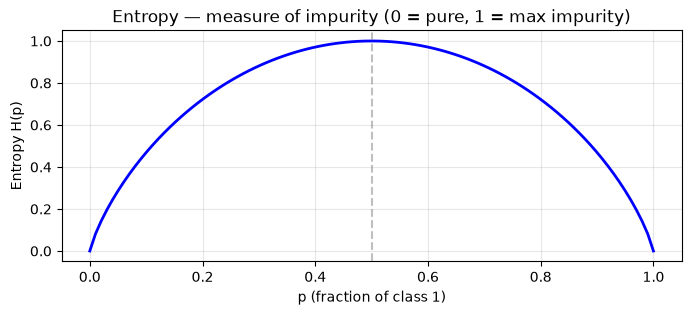

In [11]:
p_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 3))
plt.plot(p_vals, [entropy(p) for p in p_vals], "b-", linewidth=2)
plt.axvline(0.5, color="gray", ls="--", alpha=0.5)
plt.xlabel("p (fraction of class 1)")
plt.ylabel("Entropy H(p)")
plt.title("Entropy — measure of impurity (0 = pure, 1 = max impurity)")
plt.grid(alpha=0.3)
plt.show()

## 2. Decision Tree Classifier

Decision trees split data along coordinate axes. If left unrestricted, they will grow until every leaf is pure, causing extreme overfitting. The `max_depth` parameter acts as a regularizer by limiting the size of the tree.

In [12]:
# ── 2. Decision Tree Classifier ───────────────────────────────────────

print("── Decision Tree ──")

X, y = make_classification(n_samples=300, n_features=2, n_informative=2,
                            n_redundant=0, n_clusters_per_class=1,
                            random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(f"Train accuracy:  {accuracy_score(y_train, dt.predict(X_train)):.3f}")
print(f"Test accuracy:   {accuracy_score(y_test, y_pred):.3f}")
print(f"Tree depth:      {dt.get_depth()}")
print(f"Leaf nodes:      {dt.get_n_leaves()}")

── Decision Tree ──
Train accuracy:  0.969
Test accuracy:   0.920
Tree depth:      3
Leaf nodes:      6


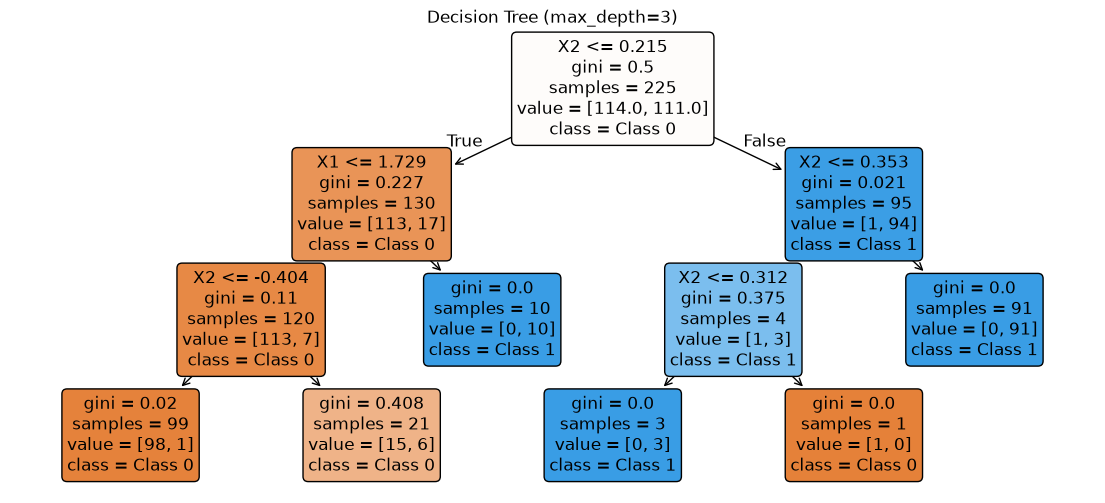

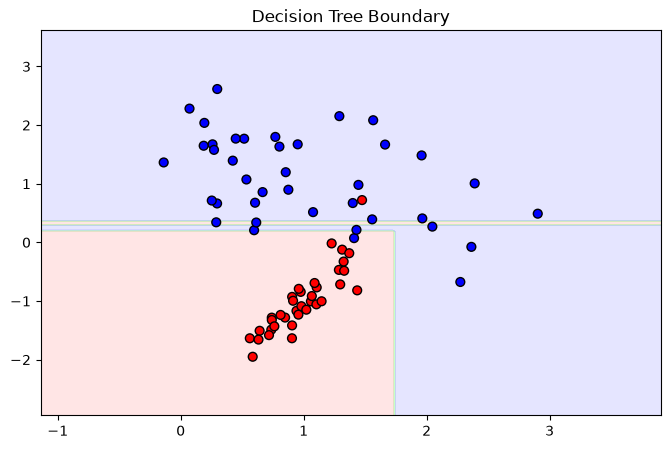

In [13]:
# Visualise tree
plt.figure(figsize=(14, 6))
plot_tree(dt, filled=True, feature_names=["X1", "X2"],
          class_names=["Class 0", "Class 1"], rounded=True)
plt.title("Decision Tree (max_depth=3)")
plt.show()

plot_decision_boundary(dt, X_test, y_test, title="Decision Tree Boundary")

## 3. Random Forest Classifier

A **Random Forest** is an ensemble of decision trees trained in parallel using two layers of randomness:
1. **Bootstrap Aggregation (Bagging)**: Each tree is trained on a random sample of the training data drawn with replacement.
2. **Random Feature Subsets**: At each node split, only a random subset of features is evaluated. This decorrelates the individual trees, lowering the overall ensemble variance without introducing bias.


── Random Forest ──
Train accuracy:  0.982
Test accuracy:   0.960
Feature importances: [0.266 0.734]


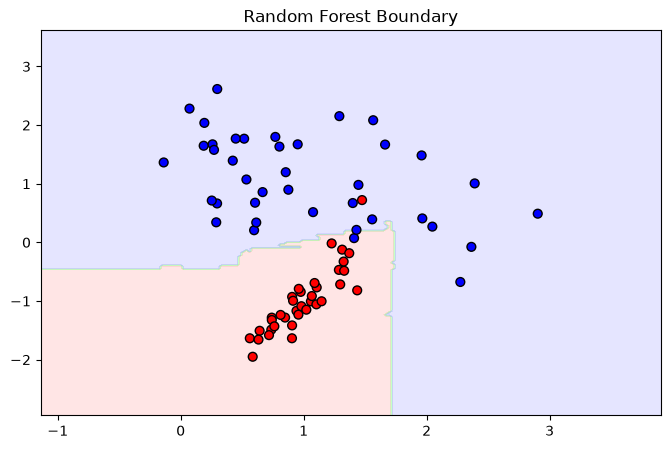

In [14]:
# ── 3. Random Forest ──────────────────────────────────────────────────

print("\n── Random Forest ──")

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Train accuracy:  {accuracy_score(y_train, rf.predict(X_train)):.3f}")
print(f"Test accuracy:   {accuracy_score(y_test, y_pred_rf):.3f}")

# Feature importance
print(f"Feature importances: {rf.feature_importances_.round(3)}")

plot_decision_boundary(rf, X_test, y_test, title="Random Forest Boundary")

## 4. XGBoost (Extreme Gradient Boosting)

Unlike Random Forests which build trees independently in parallel, **Gradient Boosting** builds trees sequentially:
- Tree $1$ is fit to the target outputs.
- Tree $2$ is fit to the residual errors (gradients) of Tree $1$.
- Each successive tree corrects the mistakes of the combined ensemble. XGBoost is a highly optimized gradient boosting implementation.

In [15]:
# ── 4. XGBoost ────────────────────────────────────────────────────────

print("\n── XGBoost ──")
try:
    import xgboost as xgb

    xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=3,
                                   learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    print(f"Test accuracy:   {accuracy_score(y_test, y_pred_xgb):.3f}")
    print(f"Feature importances: {xgb_model.feature_importances_.round(3)}")
except ImportError:
    print("XGBoost not installed. Skipping.")


── XGBoost ──
Test accuracy:   0.947
Feature importances: [0.211 0.789]


## Key Takeaways

- **Decision Tree**: Builds axis-aligned decision boundaries. Simple to interpret but prone to overfitting.
- **Entropy**: Measures node impurity. Maximizing Information Gain (impurity reduction) determines the splits.
- **Information Gain**: Formula: $IG = H(\text{parent}) - H(\text{children})$.
- **Random Forest**: Aggregates multiple randomized decision trees in parallel. It uses **bagging** and **feature subsets** to decrease model variance without changing bias.
- **XGBoost**: Employs sequential **boosting**, fitting new models to residuals of previous models. Highly expressive and standardly superior for tabular datasets.

In [16]:
# ── Key Takeaways ─────────────────────────────────────────────────────
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Decision Tree: split on feature with highest info gain       ║
║ • Entropy: measures impurity (0=pure, 1=evenly mixed)         ║
║ • Information Gain = H(parent) - weighted avg H(children)     ║
║ • max_depth: limits tree size (prevents overfitting)          ║
║ • Random Forest: bagging + random feature subset              ║
║ → reduces variance without increasing bias much               ║
║ • XGBoost: gradient boosting — sequential trees correct       ║
║   errors of previous trees (SOTA for tabular data)            ║
╚════════════════════════════════════════════════════════════════╝
""")


╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Decision Tree: split on feature with highest info gain       ║
║ • Entropy: measures impurity (0=pure, 1=evenly mixed)         ║
║ • Information Gain = H(parent) - weighted avg H(children)     ║
║ • max_depth: limits tree size (prevents overfitting)          ║
║ • Random Forest: bagging + random feature subset              ║
║ → reduces variance without increasing bias much               ║
║ • XGBoost: gradient boosting — sequential trees correct       ║
║   errors of previous trees (SOTA for tabular data)            ║
╚════════════════════════════════════════════════════════════════╝

